# Assign geojson shapes to rasterised array

Work out which geojson polygons go into each pixel of a raster array. This means we can more carefully select which polygon's data is represented in the final array. Here we show how to pick either the value of the LSOA that occupies the most land area in the pixel, and how to calculate a new value from the weighted average of several LSOA in a single pixel.

## Code setup

In [108]:
import numpy as np
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
# For converting geojson shapes to raster (array):
import rasterio
from rasterio import features

## Load data

LSOA shapes:

In [109]:
path_to_lsoa = os.path.join('..', 'data_geojson', 'ons_data', 'LSOA_Dec_2011_Boundaries_Generalised_Clipped_BGC_EW_V3.geojson')

gdf = gpd.read_file(path_to_lsoa)
# gdf = gdf.set_index('FID')
gdf = gdf.set_index('LSOA11CD')

gdf.head()

,FID,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
LSOA11CD,,,,,,,,,
E01000001,1,City of London 001A,City of London 001A,532129,181625,-0.097060,51.51810,283b0ead-f8fc-40b6-9a79-1ddd7e5c0758,"POLYGON ((532105.092 182011.23, 532162.491 181..."
E01000002,2,City of London 001B,City of London 001B,532480,181699,-0.091970,51.51868,ddce266b-7825-428c-9e0a-df66b0179a55,"POLYGON ((532634.497 181926.016, 532619.141 18..."
E01000003,3,City of London 001C,City of London 001C,532245,182036,-0.095230,51.52176,c45e358e-a794-485a-bf76-d96e5d458ea4,"POLYGON ((532135.138 182198.131, 532158.25 182..."
E01000005,4,City of London 001E,City of London 001E,533581,181265,-0.076280,51.51452,4ddaf5e4-e47f-4312-89a0-923ffec028a6,"POLYGON ((533808.018 180767.774, 533649.037 18..."
E01000006,5,Barking and Dagenham 016A,Barking and Dagenham 016A,544994,184276,0.089318,51.53876,1c04702a-b662-4cfc-aab9-2c3e0f2d5e29,"POLYGON ((545122.049 184314.931, 545271.849 18..."


In [110]:
gdf[['LSOA11NM', 'FID']].to_csv('lsoa_fid_lookup.csv')

Remove Wales:

In [111]:
gdf = gdf[gdf.index.str.contains('E')]

Set up some dummy data to show on the maps here. Let each LSOA have its own unique random integer value.

In [112]:
np.random.seed(42)

# Generate one value per LSOA:
dummy = np.arange(len(gdf), dtype=int)
# Order values randomly:
np.random.shuffle(dummy)
# Place in geodataframe:
gdf['dummy'] = dummy

View a basic map of the dummy data:

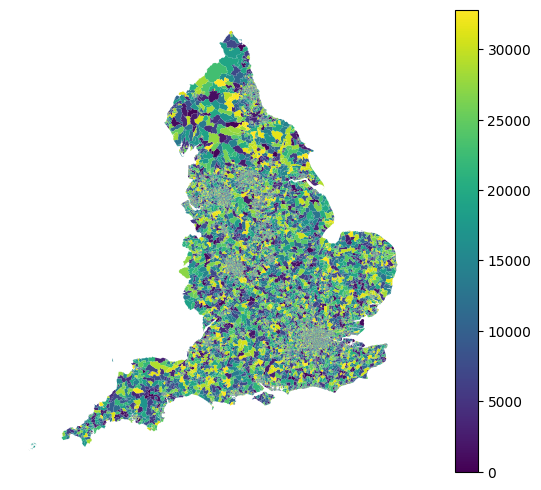

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(ax=ax, column='dummy', legend=True)
ax.axis('off')
plt.show()

## Raster setup

The following function defines how the map will be split up into pixels. The `transform` key is used for the `rasterize` function.

In [114]:
def set_up_raster_transform(gdf, pixel_size=2000):
    """
    # Code source for conversion to raster:
    # https://gis.stackexchange.com/a/475845
    """
    # Prepare some variables
    xmin, ymin, xmax, ymax = gdf.total_bounds
    width = int(np.ceil((pixel_size + xmax - xmin) // pixel_size))
    height = int(np.ceil((pixel_size + ymax - ymin) // pixel_size))
    transform = rasterio.transform.from_origin(
        xmin, ymax, pixel_size, pixel_size)

    # Store the parameters for scaling the raster image
    # to match the original vector image:
    transform_dict = {
        # For the vector image:
        'xmin': xmin,
        'ymin': ymin,
        'xmax': xmax,
        'ymax': ymax,
        # For the raster image:
        'pixel_size': pixel_size,
        'width': width,
        'height': height,
        'im_xmax': xmin + (pixel_size * width),
        'im_ymin': ymax - (pixel_size * height),
        'transform': transform
    }
    return transform_dict

Set up the transform for the England and Wales geodataframe:

In [115]:
transform_dict = set_up_raster_transform(gdf, pixel_size=2000)

transform_dict

{'xmin': 82672.0036000004,
 'ymin': 5342.69899999909,
 'xmax': 655644.7979,
 'ymax': 657534.101,
 'pixel_size': 2000,
 'width': 287,
 'height': 327,
 'im_xmax': 656672.0036000004,
 'im_ymin': 3534.101000000024,
 'transform': Affine(2000.0, 0.0, 82672.0036000004,
        0.0, -2000.0, 657534.101)}

Save a copy of this data:

In [116]:
df_transform_dict = (pd.DataFrame(transform_dict)
                     .drop('transform', axis='columns')
                     .drop_duplicates()
                     .transpose())

df_transform_dict.to_csv(
    # 'rasterise_geojson_fid_ew_transform_dict.csv', header=False)
    'rasterise_geojson_fid_eng_transform_dict.csv', header=False)

Use this data to define the boundaries of the pixel data (for imshow extent). The `rasterise` function uses the most southern and western point as its base, so the "true" top left corner will be the same in the original geojson and in the raster image bounds, but the bottom and right sides will be slightly different because the raster image has an integer number of pixels of fixed width and height. So make sure the extent is defined using a matching top left corner and different bottom and right values.

In [117]:
extent = [
    transform_dict['xmin'],
    transform_dict['im_xmax'],
    transform_dict['im_ymin'],
    transform_dict['ymax'],
]

# Define the middle coordinates of each pixel
# for checking that the plotted pixels line up as expected.
x_mids = np.arange(extent[0] + transform_dict['pixel_size'] * 0.5, extent[1],
                   transform_dict['pixel_size'])
y_mids = np.arange(extent[3] - transform_dict['pixel_size'] * 0.5, extent[2],
                   -transform_dict['pixel_size'])

In [118]:
area_each_pixel = transform_dict['pixel_size']**2.0

area_each_pixel

4000000.0

The following function plots the original geojson data and the resulting rasterisation side-by-side.

In [119]:
def plot_geojson_vs_raster(gdf, raster, extent, xlim=[None, None], ylim=[None, None], x_mids=[], y_mids=[], title_right=''):
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 7), gridspec_kw={'width_ratios': [1.0, 1.0, 0.05], 'wspace': 0.05})
    
    # Original data for comparison:
    gdf.plot(ax=axs[0], column='dummy', legend=True, edgecolor='k', cax=axs[2], legend_kwds={'label': 'Dummy data'})
    
    # Raster:
    axs[1].imshow(raster, origin='lower', extent=extent, interpolation='none')
    # Geojson outline over raster:
    gdf.plot(ax=axs[1], column='dummy', legend=False, facecolor='None', edgecolor='k')
    
    for ax in axs[:-1]:
        # Pixel borders:
        for x_mid in x_mids:
            ax.axvline(x_mid + 0.5 * transform_dict['pixel_size'], color='grey')
        for y_mid in y_mids:
            ax.axhline(y_mid + 0.5 * transform_dict['pixel_size'], color='grey')    
    
        ax.axis('off')
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
    
    axs[0].set_title('Original data')
    axs[1].set_title(title_right)
    
    plt.show()

British National Grid coordinates for cropping the images to the Exe estuary:

In [120]:
xlim_exe = (285000, 315000)
ylim_exe = (70000, 100000)

## rasterio rasterize

See how the map is turned to raster using the `rasterio` package and its `rasterize` function.

The following function is a wrapper for `rasterize`.

In [121]:
def make_raster_from_vectors(
        _geometry,
        vals_for_colours,
        height,
        width,
        transform
        ):
    """
    # Burn geometries for left-hand map:

    """
    shapes = ((geom, value) for geom, value in zip(_geometry, vals_for_colours))
    burned = rasterio.features.rasterize(
        shapes=shapes,
        out_shape=(height, width),
        fill=np.NaN,
        transform=transform,
        all_touched=True
    )
    burned = np.flip(burned, axis=0)
    return burned

Run the function:

In [122]:
raster_rasterio = make_raster_from_vectors(
    gdf['geometry'],
    gdf['dummy'],
    transform_dict['height'],
    transform_dict['width'],
    transform_dict['transform']
)

Are all values integers?

In [123]:
mask = ~np.isnan(raster_rasterio)

(raster_rasterio[mask] == raster_rasterio[mask].astype(int)).all()

True

All values are integers so expect that the rasterisation is just assigning one LSOA to each pixel rather than averaging values across multiple LSOA.

Show a map of the resulting rasterisation in the Exe estuary.

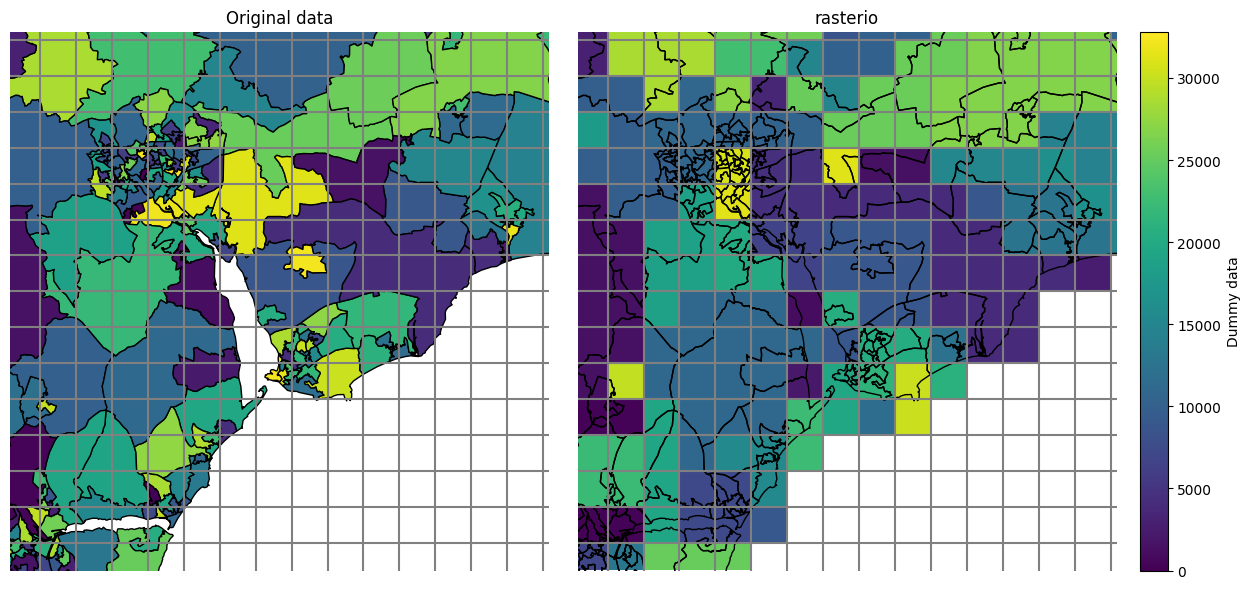

In [124]:
plot_geojson_vs_raster(gdf, raster_rasterio, extent, xlim_exe, ylim_exe, x_mids, y_mids, title_right='rasterio')

rasterio seems to be assigning the dummy data to the pixels in the order that the LSOA appear in the geodataframe. If multiple LSOA appear in the same pixel, the dummy value assigned to the pixel is for just one of those LSOA. This has the effect of picking one of the LSOA at random rather than looking at which value is most appropriate.

## Custom value assignment

Instead set up a way to look at which LSOA are in each pixel and how much of its area they cover. Note: this method will only with British National Grid or other Cartesian coordinate projections.

In the following cell, we loop over each pixel in turn starting with the first column and working down. We find the bounds of the pixel and limit the gdf to those bounds. Then if there are any LSOA in the bounds, we calculate the total area occupied by the LSOA (which is not always the full area of the cell if it includes the sea or the Scottish border), and then find the proportion of the land area that is represented by each LSOA. These results are stored in a dictionary and then a DataFrame with the pixels identified by a single value, the column + row number.

Store the LSOA in terms of their FID in the geojson file because FID are integers and so it should take up less file space than LSOA codes.

In [ ]:
# Store results in here:
dict_props = {}
# Keep track of pixel number:
total_to_check = transform_dict['height'] * transform_dict['width']
i = 0
for xi in range(transform_dict['width']):
    for yi in range(transform_dict['height']):
        perc_done = 100.0 * (i + 1) / total_to_check
        print(f'{perc_done:5.1f}% of pixels checked', end='\r')
        # Pixel limits:
        pixel_limits_lrbt = [
            extent[0] + xi * transform_dict['pixel_size'],
            extent[0] + (xi + 1) * transform_dict['pixel_size'],
            extent[2] + yi * transform_dict['pixel_size'],
            extent[2] + (yi + 1) * transform_dict['pixel_size'],
        ]
        # Turn this into bounding box (xmin, ymin, xmax, ymax):
        bbox = [pixel_limits_lrbt[p] for p in [0, 2, 1, 3]]
        # Limit gdf to this pixel:
        gdf_here = gpd.clip(gdf, bbox)#.reset_index()

        if len(gdf_here) > 0:
            # Find proportion of the constituent LSOAs by area:
            series_area_props = gdf_here.area / gdf_here.area.sum()
            # Sort LSOA IDs and proportions by decreasing proportion:
            fids = series_area_props.index.values
            props = series_area_props.values
            inds = np.argsort(props)[::-1]
    
            # Store result:
            dict_props[i] = {
                # 'FID': list(fids[inds]),
                'LSOA11CD_props': list(fids[inds]),
                'area_props': [round(p, 3) for p in props[inds]],
                'area_total': round(gdf_here.area.sum(), 1),
            }
        # Iterate:
        i += 1

# Convert the results to dataframe:
df_props = pd.DataFrame(dict_props.values(), index=dict_props.keys())
df_props.index.name = 'i'
# Add a column for the LSOA that occupies the most space in the pixel:
# df_props['FID_majority'] = [f[0] for f in df_props['FID'].tolist()]
df_props['LSOA11CD_majority'] = [f[0] for f in df_props['LSOA11CD_props'].tolist()]

In [127]:
i

93849

Save a copy of the results:

In [128]:
# df_props.to_csv('rasterise_geojson_fid_ew.csv')
# df_props.to_csv('rasterise_geojson_lsoa11cd_ew.csv')
df_props.to_csv('rasterise_geojson_lsoa11cd_eng.csv')

In [ ]:
df_props = pd.read_csv('rasterise_geojson_lsoa11cd_eng.csv', index_col=0)
# Pick out pixel identifier column:
df_props = df_props.reset_index()
df_props = df_props.rename(columns={'index': 'i'})
# Convert strings back to lists:
df_props['LSOA11CD_props'] = [c[2:-2].split("', '") for c in df_props['LSOA11CD_props']]
df_props['area_props'] = [[float(v) for v in c[1:-1].split(", ")] for c in df_props['area_props']]

In [133]:
# Calculate how much of each pixel contains land (as opposed to sea
# or other countries):
df_props['total_area_covered'] = df_props['area_total'] / area_each_pixel
# Pick out pixels that mostly contain no land:
mask_sea = (df_props['total_area_covered'] <= (1.0 / 3.0))
# Remove the data here so that they're not shown.
df_props = df_props.loc[~mask_sea]

Check some of the results:

In [134]:
df_props[210:220]

,i,LSOA11CD_props,area_props,area_total,LSOA11CD_majority,total_area_covered
275,15060,"[E01018829, E01018830]","[0.791, 0.209]",4000000.0,E01018829,1.000000
276,15061,"[E01018817, E01018829, E01018820]","[0.57, 0.371, 0.059]",4000000.0,E01018817,1.000000
277,15062,"[E01018820, E01018817, E01018819]","[0.728, 0.227, 0.045]",4000000.0,E01018820,1.000000
278,15063,"[E01018820, E01018843, E01018819, E01018826]","[0.947, 0.038, 0.007, 0.007]",4000000.0,E01018820,1.000000
279,15064,"[E01018843, E01018820, E01018852, E01018826, E...","[0.698, 0.139, 0.072, 0.047, 0.043]",4000000.0,E01018843,1.000000
280,15065,"[E01018843, E01018852]","[0.949, 0.051]",4000000.0,E01018843,1.000000
281,15066,"[E01018843, E01018852, E01018842]","[0.893, 0.089, 0.018]",4000000.0,E01018843,1.000000
282,15067,"[E01018844, E01018842, E01018843, E01018833]","[0.402, 0.339, 0.176, 0.084]",2746001.6,E01018844,0.686500
286,15375,[E01018920],[1.0],1945713.4,E01018920,0.486428
287,15376,[E01018920],[1.0],3606705.6,E01018920,0.901676


## Raster with majority value

Make a new raster image where each pixel uses the data for the LSOA that occupies the most land area in that pixel.

Build a new array out of the proportion data to find which LSOA is represented where:

In [135]:
def convert_df_to_2darray(df_raster, data_col, transform_dict):
    # Make a 1D array with all pixels, not just valid ones:
    raster_arr_maj = np.full(
        int(transform_dict['height'] * transform_dict['width']), np.NaN)
    # Update the values of valid pixels:
    raster_arr_maj[df_raster['i'].values] = df_raster[data_col].values
    # Reshape into rectangle:
    raster_arr_maj = raster_arr_maj.reshape(
        (int(transform_dict['width']), int(transform_dict['height']))).transpose()
    return raster_arr_maj

In [136]:
# ----- Majority vote data -----
# Bring in the data to be displayed:
df_props = pd.merge(
    df_props,
    gdf[['dummy']].reset_index(),
    left_on='LSOA11CD_majority',
    right_on='LSOA11CD',
    how='left',
    )

In [137]:
raster_arr_maj = convert_df_to_2darray(df_props, 'dummy', transform_dict)

View results:

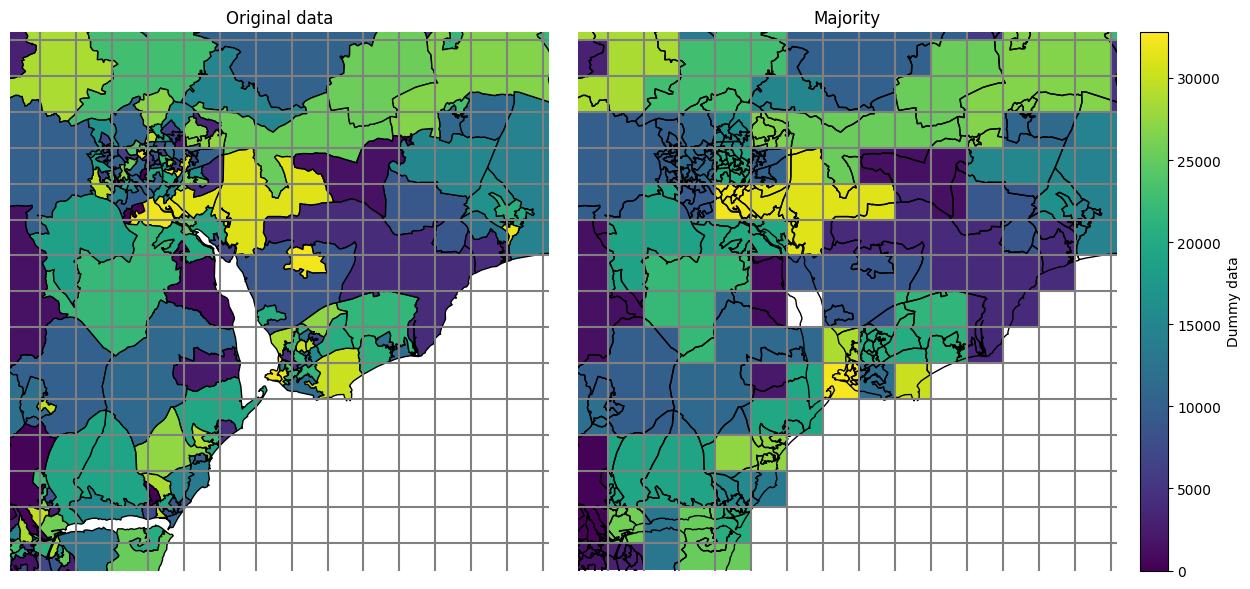

In [138]:
plot_geojson_vs_raster(gdf, raster_arr_maj, extent, xlim_exe, ylim_exe, x_mids, y_mids, title_right='Majority')

This method works pretty well in most cases. There are several pixels where the majority LSOA covers barely more area than the next biggest LSOA.

## Raster with scaled data

Make a new raster image where each pixel takes a weighted combination of the values of all LSOA in the pixel.

Build a new array out of the area proportion data:

In [151]:
raster_arr_share = np.full((int(transform_dict['height']), int(transform_dict['width'])), np.NaN)

for i in df_props['i']:
    xi = i // raster_arr_share.shape[0]
    yi = i % raster_arr_share.shape[0]
    # Check that enough area is covered:
    total_area_covered = df_props.loc[df_props['i'] == i, 'area_total'].values[0] / area_each_pixel
    # If enough area covered, update the pixel value:
    if total_area_covered >= (1.0 / 3.0):
        # Pick out the LSOAs in this pixel and the proportion they take up:
        lsoas_here = df_props.loc[df_props['i'] == i, 'LSOA11CD_props'].values[0]
        props_here = df_props.loc[df_props['i'] == i, 'area_props'].values[0]
        # Pick out the data for these LSOAs:
        vals_here =  gdf.loc[lsoas_here, 'dummy'].values
        # Scale data by proportions and sum:
        val = np.sum(vals_here * props_here)
        # Update array:
        raster_arr_share[yi, xi] = val

View results:

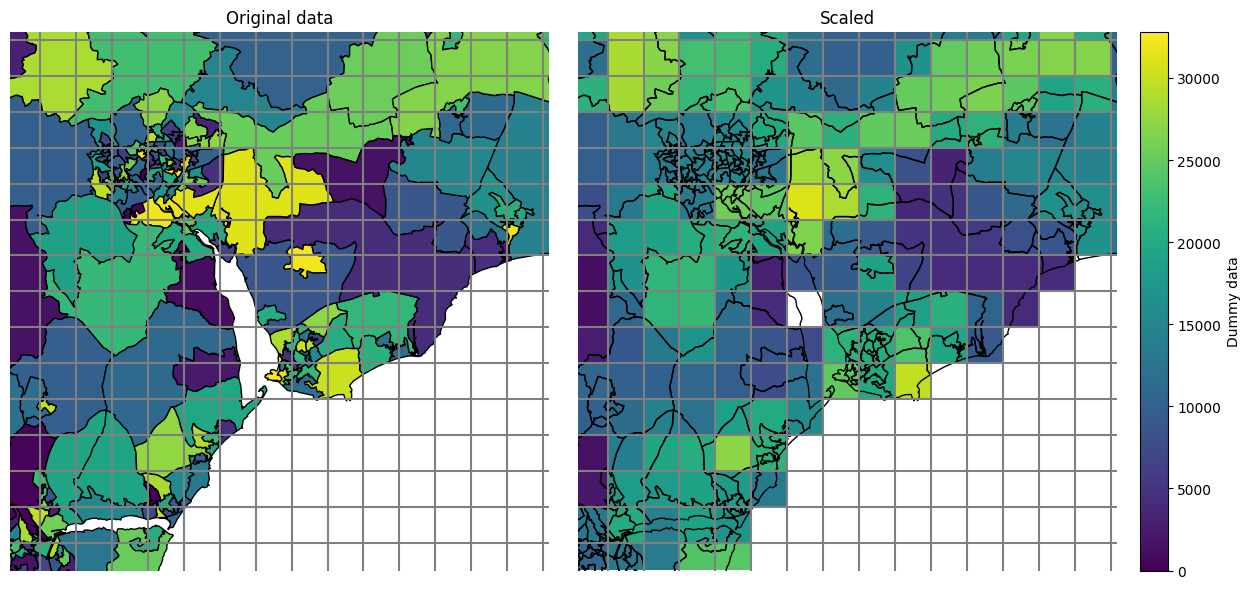

In [152]:
plot_geojson_vs_raster(gdf, raster_arr_share, extent, xlim_exe, ylim_exe, x_mids, y_mids, title_right='Scaled')

The centres of prominent distinct LSOA can still be picked out in the scaled map. Regions that contain lots of borders have been smoothed over that a lot of pixels now have more middling values.

Are all values integers?

In [153]:
mask = ~np.isnan(raster_arr_share)

(raster_arr_share[mask] == raster_arr_share[mask].astype(int)).all()

False

The results no longer have integer values because of the averaging.

## Compare methods

View results across all of England and just in the Exe estuary:

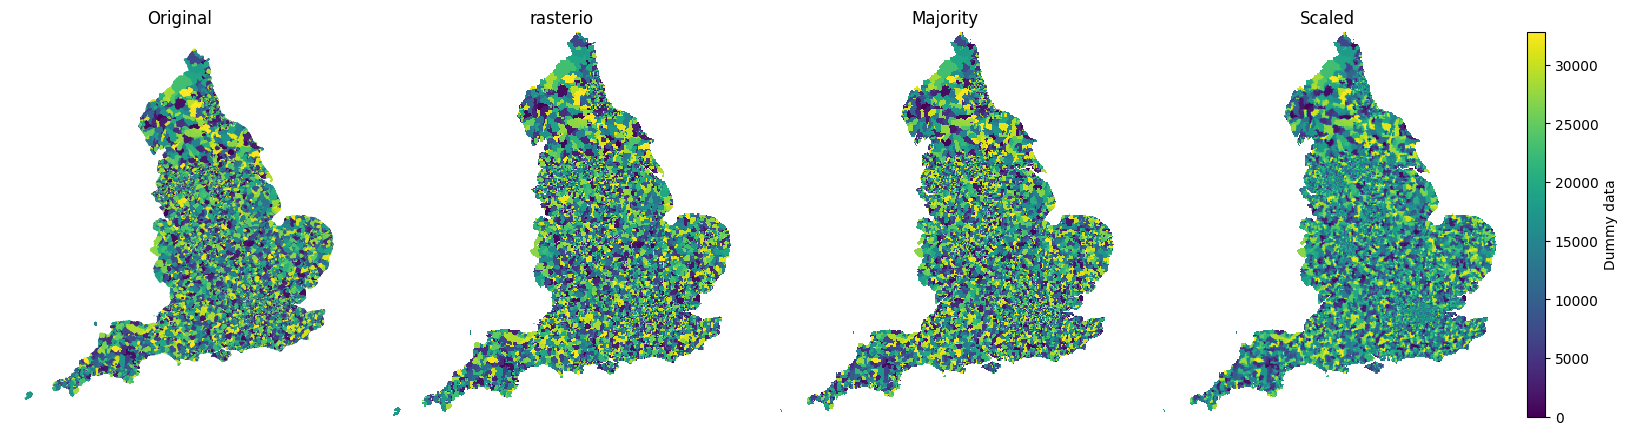

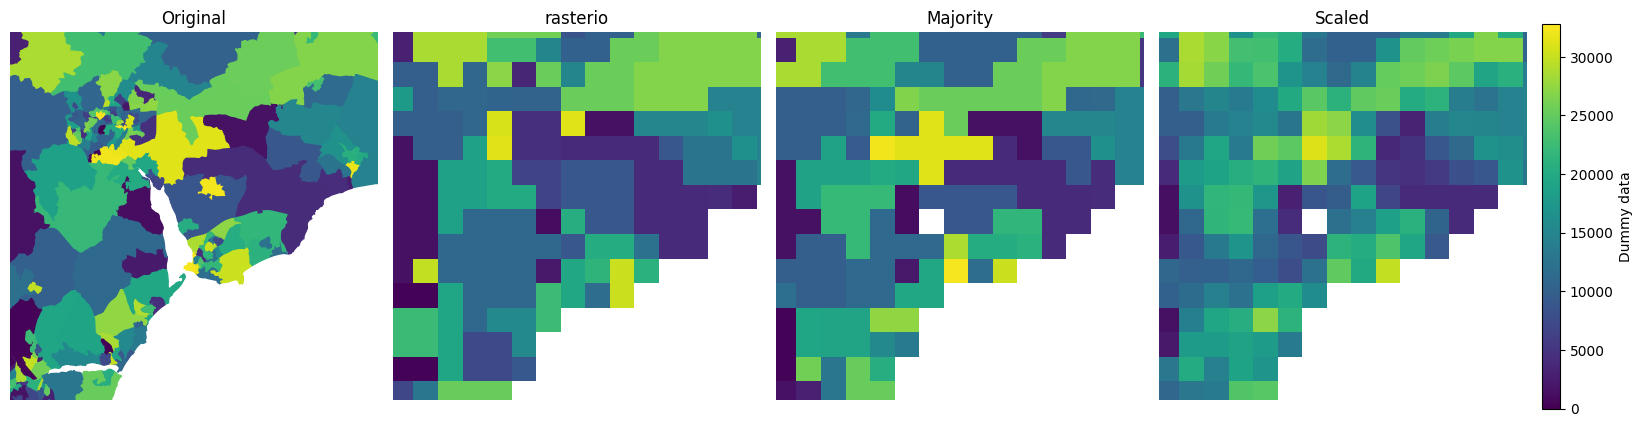

In [154]:
xlims = [[None, None], xlim_exe]
ylims = [[None, None], ylim_exe]

for x, xlim in enumerate(xlims):
    ylim = ylims[x]
    gs_dict = {'width_ratios': [1.0, 1.0, 1.0, 1.0, 0.05], 'wspace': 0.05}
    fig, axs = plt.subplots(1, 5, figsize=(20, 5), gridspec_kw=gs_dict)
    
    # Original data for comparison:
    gdf.plot(ax=axs[0], column='dummy', edgecolor='face',
             legend=True, cax=axs[4], legend_kwds={'label': 'Dummy data'})
    # Raster:
    axs[1].imshow(raster_rasterio, origin='lower', extent=extent, interpolation='none')
    axs[2].imshow(raster_arr_maj, origin='lower', extent=extent, interpolation='none')
    axs[3].imshow(raster_arr_share, origin='lower', extent=extent, interpolation='none')

    for ax in axs[:4]:
        ax.axis('off')            
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

    axs[0].set_title('Original')
    axs[1].set_title('rasterio')
    axs[2].set_title('Majority')
    axs[3].set_title('Scaled')
                        
    plt.show()

## Conclusion

Both the majority and scaled methods give a more accurate transcription of the data to raster than the default `rasterio` function because they allow for multiple regions sharing a single pixel.

Which of the two methods is better to use would depend on the application. Where a smooth continuous change in data with area is expected, then the scaling method won't result in so drastically changed values as in this example.

This method could be used to create a raster setup in advance and so avoid using a geojson later down the line, for example in use with Streamlit apps. The resulting area proportions file for all of England and Wales is a few MB. The raster image could be created using that file and the dictionary with the raster setup, e.g. image boundaries and pixel sizes.